 图像处理涉及到四个坐标系：
 1.世界坐标系，描述相机位置
 2.相机坐标系，光电为圆心

图像坐标系与像素坐标系
像素坐标系和图像坐标系都在成像平面上，只是各自的原点和度量单位不一样。图像坐标系的原点为相机光轴与成像平面的交点，通常情况下是成像平面的中点或者叫principal point。图像坐标系的单位是mm，属于物理单位，而像素坐标系的单位是pixel，我们平常描述一个像素点都是几行几列。所以这二者之间的转换如下：其中dx和dy表示每一列和每一行分别代表多少mm，即1pixel=dx mm 

![alt text](image.png)

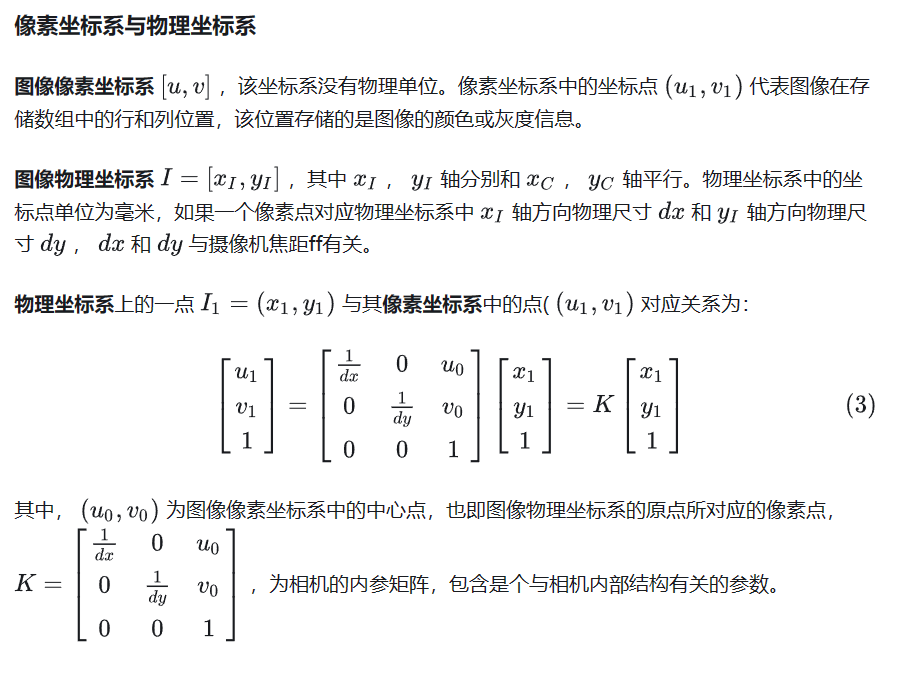

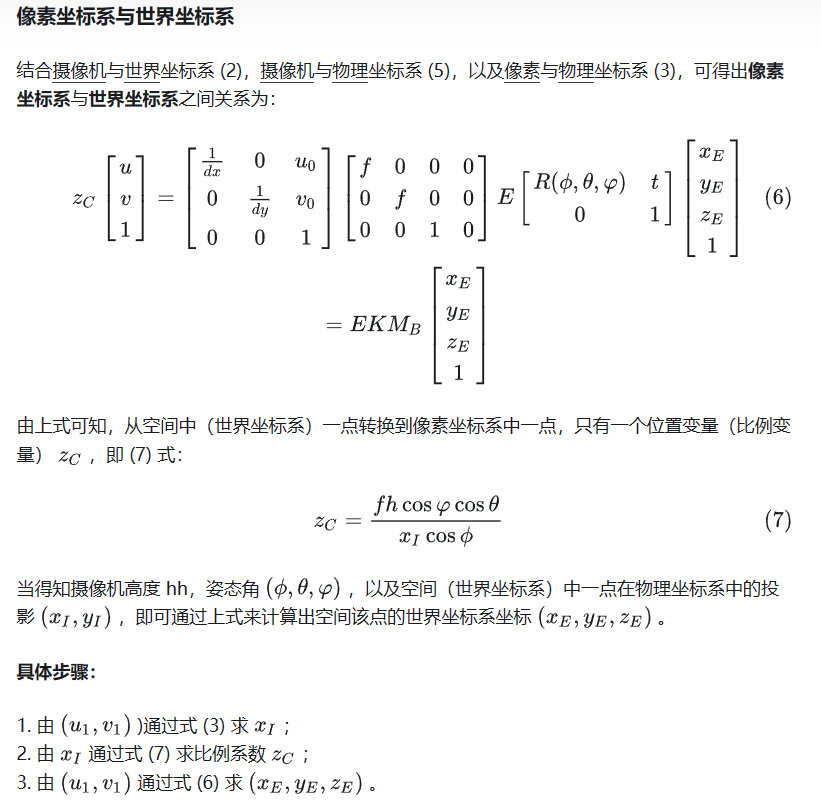

In [19]:
import numpy as np
from phantom import phantom
import matplotlib.pyplot as plt
import math

1.创建并定义Grid,实现世界坐标系与像素坐标系相互转换


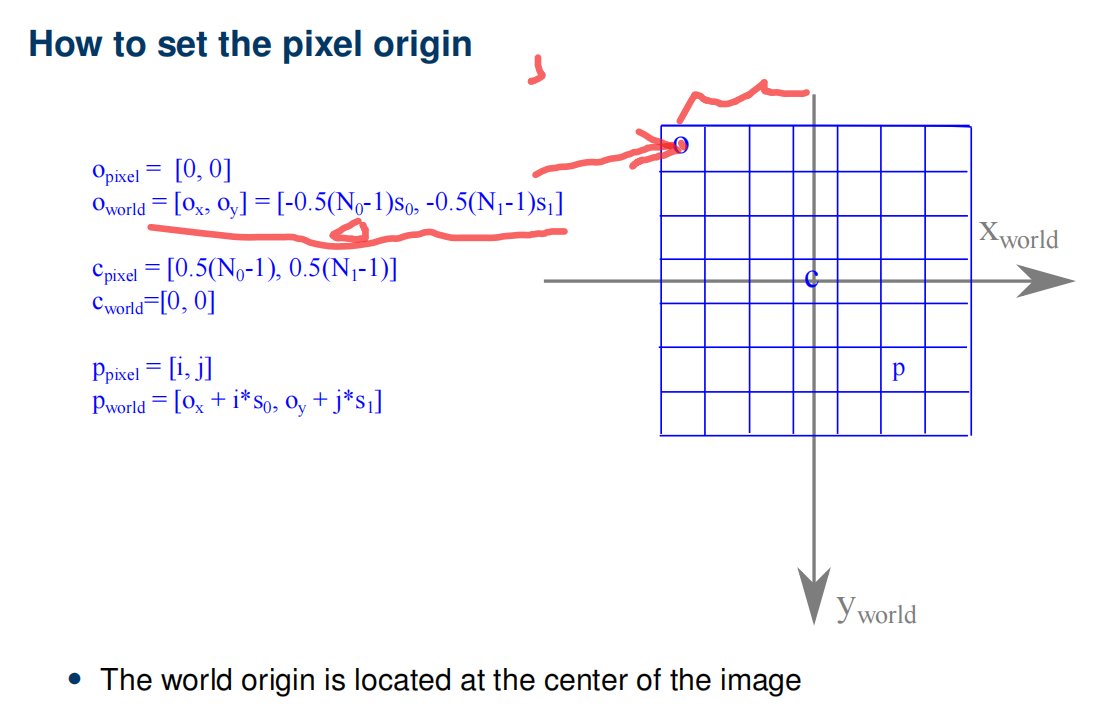
!注意：世界坐标系原点不同公式不同

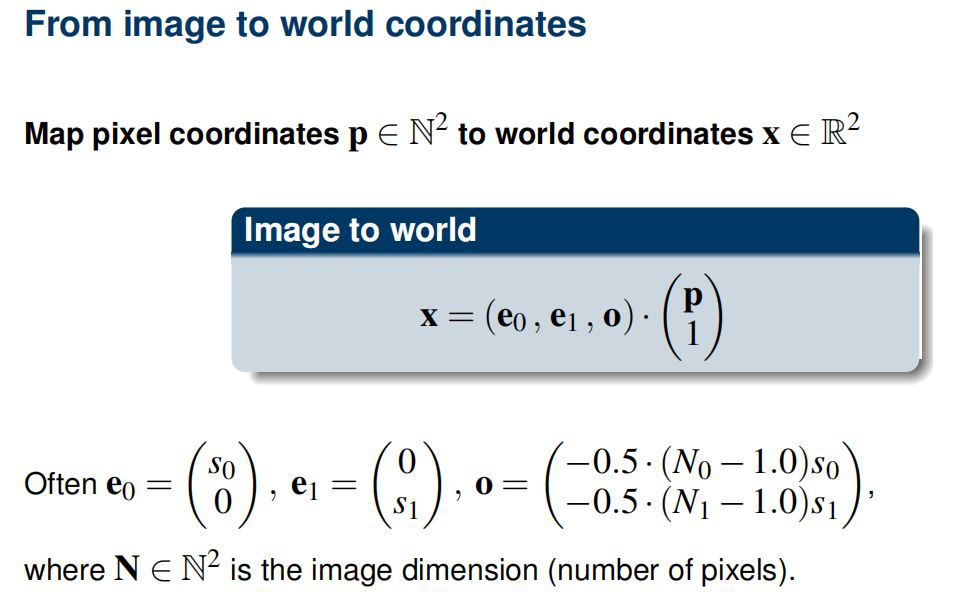


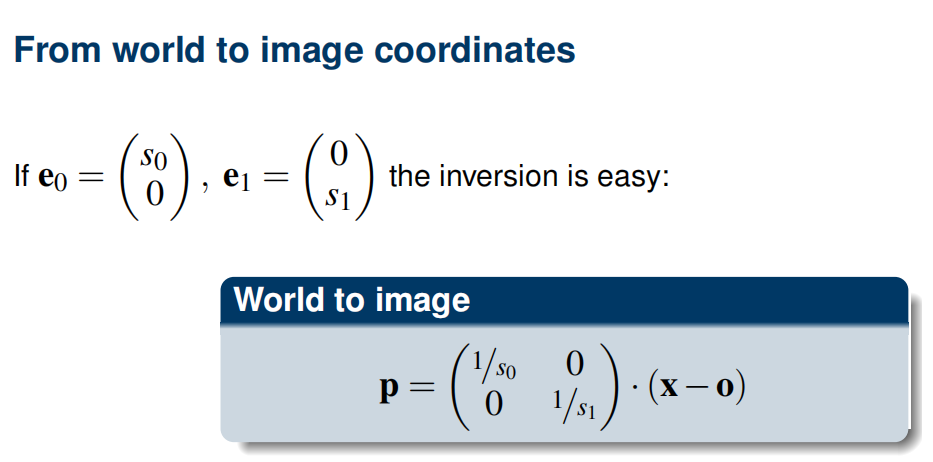

In [20]:
class Grid:

    def __init__(self, height, width, spacing):
        self.height =  height
        self.width = width  
        self.spacing = spacing
        self.origin = (-0.5 * ( height - 1) * spacing[0] , -0.5 * ( width - 1) * spacing[1])  #参考O_world
        self.buffer = np.zeros((height, width))

    def set_at_index(self, i, j, val):
        self.buffer[i, j] = val


    def get_at_index(self, i, j):
        return self.buffer[i, j]


    def get_at_physical(self, x, y):#From world to image coordinates
        # Convert physical coordinates to indices
        from interpolate import interpolate 
        # i = 1/self.spacing[0] * (x - self.origin[0])
        # j = 1/self.spacing[1] * (y - self.origin[1])
        
        i, j = self.physical_to_index( x, y)
        
        # Interpolate to get value at physical coordinates
        return interpolate(self, i, j)
        

    def index_to_physical(self, i, j):
        x = self.origin[0] + i * self.spacing[0]
        y = self.origin[1] + j * self.spacing[1]
        return x, y

    def physical_to_index(self, x, y):
        i = (x - self.origin[0]) / self.spacing[0]
        j = (y - self.origin[1]) / self.spacing[1]
        return int(round(i)), int(round(j))
       

    def get_size(self):
        return self.height, self.width

    def set_origin(self, origin):
        self.origin = origin

    def get_origin(self):
        return self.origin

    def set_spacing(self, spacing):
        self.spacing = spacing

    def get_spacing(self):
        return self.spacing

    def get_buffer(self):
        return self.buffer

    def set_buffer(self, buffer):
        self.buffer = buffer

2.define interpolation

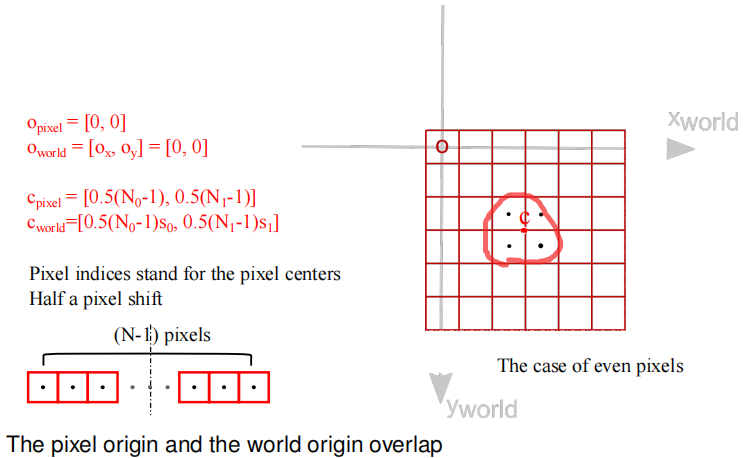

双线性插值(Bilinear Interpolation):在数学上，双线性插值是有两个变量的插值函数的线性插值扩展，其核心思想是在两个方向上分别进行一次线性插值。 
 对于一个目的像素，设置坐标通过反向变换得到的浮点坐标为(i+u,j+v) (其中i、j均为浮点坐标的整数部分，u、v为浮点坐标的小数部分，是取值[0,1)区间的浮点数)，则这个像素得值 f(i+u,j+v) 可由原图像中坐标为 (i,j)、(i+1,j)、(i,j+1)、(i+1,j+1)所对应的周围四个像素的值决定，即：f(i+u,j+v) = (1-u)(1-v)f(i,j) + (1-u)vf(i,j+1) + u(1-v)f(i+1,j) + uvf(i+1,j+1) 
 其中f(i,j)表示源图像(i,j)处的的像素值，以此类推。



In [21]:

def interpolate(grid, x, y):
    # Calculate the four surrounding data points in range [0,1]
    # math.floor() 函数取得 x 和 y 的整数部分，然后计算得到 x 和 y 的小数部分，以及小数部分加一后的值。
    x_floor = math.floor(x)
    y_floor = math.floor(y)
    x_floor_plus_one = x_floor + 1
    y_floor_plus_one = y_floor + 1
    x_p = x - x_floor
    y_p = y - y_floor

    # Check boundary conditions
    if x_floor < 0 or x_floor > grid.get_size()[0] - 1:
        x_floor = None
    if x_floor_plus_one < 0 or x_floor_plus_one > grid.get_size()[0] - 1:
        x_floor_plus_one = None

    if y_floor < 0 or y_floor > grid.get_size()[1] - 1:
        y_floor = None
    if y_floor_plus_one < 0 or y_floor_plus_one > grid.get_size()[1] - 1:
        y_floor_plus_one = None
    # Get function values of the data points and setup function matrix
    # 通过 grid.get_at_index() 函数获取对应坐标点的函数值，如果某个坐标为 None，则对应的函数值为 0.0
    a = grid.get_at_index(x_floor, y_floor) if (x_floor is not None and y_floor is not None) else 0.0
    b = grid.get_at_index(x_floor, y_floor_plus_one) if \
        (x_floor is not None and y_floor_plus_one is not None) else 0.0
    c = grid.get_at_index(x_floor_plus_one, y_floor) if \
        (x_floor_plus_one is not None and y_floor is not None) else 0.0
    d = grid.get_at_index(x_floor_plus_one, y_floor_plus_one) if \
        (x_floor_plus_one is not None and y_floor_plus_one is not None) else 0.0

    #                                       [f(0,0) f(0,1)] [1-y]
    # Calculate Interp value with    [1-x x] [f(1,0) f(1,1)] [ y ]
    val_matrix = np.array([[a, b], [c, d]])

    return np.matmul(np.matmul(np.array([1 - x_p, x_p]), val_matrix), np.transpose(np.array([1 - y_p, y_p])))

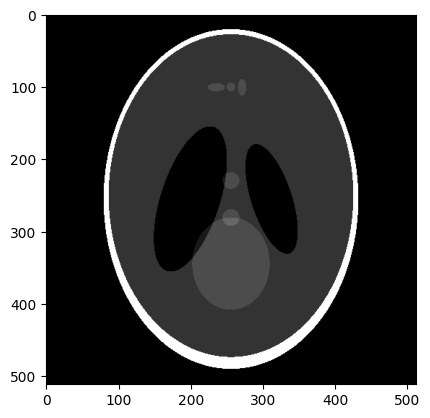

In [22]:
from phantom import phantom
import matplotlib.pyplot as plt

shepp_logan = phantom(n = 512, p_type = 'Modified Shepp-Logan', ellipses = None)
plt.imshow(shepp_logan)
plt.gray()
plt.show()

In [23]:

def phantom (n = 256, p_type = 'Modified Shepp-Logan', ellipses = None):
	"""
	 phantom (n = 256, p_type = 'Modified Shepp-Logan', ellipses = None)
	
	Create a Shepp-Logan or modified Shepp-Logan phantom.

	A phantom is a known object (either real or purely mathematical) 
	that is used for testing image reconstruction algorithms.  The 
	Shepp-Logan phantom is a popular mathematical model of a cranial
	slice, made up of a set of ellipses.  This allows rigorous 
	testing of computed tomography (CT) algorithms as it can be 
	analytically transformed with the radon transform (see the 
	function `radon').
	
	Inputs
	------
	n : The edge length of the square image to be produced.
	
	p_type : The type of phantom to produce. Either 
	  "Modified Shepp-Logan" or "Shepp-Logan".  This is overridden
	  if `ellipses' is also specified.
	
	ellipses : Custom set of ellipses to use.  These should be in 
	  the form
	  	[[I, a, b, x0, y0, phi],
	  	 [I, a, b, x0, y0, phi],
	  	 ...]
	  where each row defines an ellipse.
	  I : Additive intensity of the ellipse.
	  a : Length of the major axis.
	  b : Length of the minor axis.
	  x0 : Horizontal offset of the centre of the ellipse.
	  y0 : Vertical offset of the centre of the ellipse.
	  phi : Counterclockwise rotation of the ellipse in degrees,
	        measured as the angle between the horizontal axis and 
	        the ellipse major axis.
	  The image bounding box in the algorithm is [-1, -1], [1, 1], 
	  so the values of a, b, x0, y0 should all be specified with
	  respect to this box.
	
	Output
	------
	P : A phantom image.
	
	Usage example
	-------------
	  import matplotlib.pyplot as pl
	  P = phantom ()
	  pl.imshow (P)
	
	References
	----------
	Shepp, L. A.; Logan, B. F.; Reconstructing Interior Head Tissue 
	from X-Ray Transmissions, IEEE Transactions on Nuclear Science,
	Feb. 1974, p. 232.
	
	Toft, P.; "The Radon Transform - Theory and Implementation", 
	Ph.D. thesis, Department of Mathematical Modelling, Technical 
	University of Denmark, June 1996.
	
	"""
	
	if (ellipses is None):
		ellipses = _select_phantom (p_type)
	elif (np.size (ellipses, 1) != 6):
		raise AssertionError ("Wrong number of columns in user phantom")
	
	# Blank image
	p = np.zeros ((n, n))

	# Create the pixel grid
	ygrid, xgrid = np.mgrid[-1:1:(1j*n), -1:1:(1j*n)]

	for ellip in ellipses:
		I   = ellip [0]
		a2  = ellip [1]**2
		b2  = ellip [2]**2
		x0  = ellip [3]
		y0  = ellip [4]
		phi = ellip [5] * np.pi / 180  # Rotation angle in radians
		
		# Create the offset x and y values for the grid
		x = xgrid - x0
		y = ygrid - y0
		
		cos_p = np.cos (phi) 
		sin_p = np.sin (phi)
		
		# Find the pixels within the ellipse
		locs = (((x * cos_p + y * sin_p)**2) / a2 
              + ((y * cos_p - x * sin_p)**2) / b2) <= 1
		
		# Add the ellipse intensity to those pixels
		p [locs] += I

	return p


def _select_phantom (name):
	if (name.lower () == 'shepp-logan'):
		e = _shepp_logan ()
	elif (name.lower () == 'modified shepp-logan'):
		e = _mod_shepp_logan ()
	else:
		raise ValueError ("Unknown phantom type: %s" % name)
	
	return e


def _shepp_logan ():
	#  Standard head phantom, taken from Shepp & Logan
	return [[   2,   .69,   .92,    0,      0,   0],
	        [-.98, .6624, .8740,    0, -.0184,   0],
	        [-.02, .1100, .3100,  .22,      0, -18],
	        [-.02, .1600, .4100, -.22,      0,  18],
	        [ .01, .2100, .2500,    0,    .35,   0],
	        [ .01, .0460, .0460,    0,     .1,   0],
	        [ .02, .0460, .0460,    0,    -.1,   0],
	        [ .01, .0460, .0230, -.08,  -.605,   0],
	        [ .01, .0230, .0230,    0,  -.606,   0],
	        [ .01, .0230, .0460,  .06,  -.605,   0]]

def _mod_shepp_logan ():
	#  Modified version of Shepp & Logan's head phantom, 
	#  adjusted to improve contrast.  Taken from Toft.
	return [[   1,   .69,   .92,    0,      0,   0],
	        [-.80, .6624, .8740,    0, -.0184,   0],
	        [-.20, .1100, .3100,  .22,      0, -18],
	        [-.20, .1600, .4100, -.22,      0,  18],
	        [ .10, .2100, .2500,    0,    .35,   0],
	        [ .10, .0460, .0460,    0,     .1,   0],
	        [ .10, .0460, .0460,    0,    -.1,   0],
	        [ .10, .0460, .0230, -.08,  -.605,   0],
	        [ .10, .0230, .0230,    0,  -.606,   0],
	        [ .10, .0230, .0460,  .06,  -.605,   0]]

#def ?? ():
#	# Add any further phantoms of interest here
#	return np.array (
#	 [[ 0, 0, 0, 0, 0, 0],
#	  [ 0, 0, 0, 0, 0, 0]])

0.19999999999999996
0.29999999999999993
(-55.25, 71.75)
(255, 476)


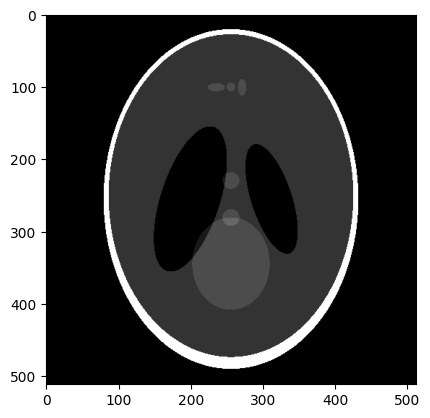

In [24]:
shepp = phantom(n=512, p_type='Modified Shepp-Logan', ellipses=None)

# shepp = utils.shepp_logan(512)
shepp_grid = Grid(512, 512, [0.5, 0.5])
shepp_grid.set_buffer(shepp)

print(shepp_grid.get_at_physical(-90.25, 47.5))
print(shepp_grid.get_at_physical(11.75, -4.0))

print(shepp_grid.index_to_physical(145, 399))
print(shepp_grid.physical_to_index(-0.4, 110.4))

plt.imshow(shepp_grid.buffer)
plt.gray()
plt.show()